# 07 Theory stress tests for the appendix

This notebook produces the supporting empirical checks for the formal results that are not meant to carry the main empirical narrative. The main-body notebooks estimate the design-risk components on public data and semi-synthetic domains. This notebook isolates the mathematical claims and stress-tests them in small controlled settings where the relevant population quantities are known.

In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().resolve()
while PROJECT_ROOT.name != "online_experiment_designs_under_interference" and PROJECT_ROOT != PROJECT_ROOT.parent:
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT / "code" / "src"))

from config import ProjectPaths
from figures import (
    plot_assignment_unit_mde,
    plot_catalog_approximation,
    plot_minimax_transport_check,
    plot_transport_bound_checks,
)
from progress import ProgressLogger
from tables import write_table
from theory_checks import (
    run_assignment_unit_mde_grid,
    run_catalog_approximation_sensitivity,
    run_minimax_transport_optimality_check,
    run_transport_bias_bound_stress,
    theory_experiment_map,
)
from IPython.display import Image, display

paths = ProjectPaths.from_anywhere(PROJECT_ROOT)
paths.ensure()
progress = ProgressLogger("07-theory")

## Theory-to-artifact map

The table below is the audit trail for the paper. Results that drive the main story are tested in the main-body notebooks. Results that justify the mathematical machinery, such as transport tightness and catalog approximation, are tested here and placed in the appendix.

In [2]:
coverage = theory_experiment_map()
write_table(coverage, paths.table_dir / "07_theory_to_experiment_map.csv")
coverage

[saved] /home/apex/Documents/ranking_sys/notebooks/writing/online_experiment_designs_under_interference/code/artifacts/tables/07_theory_to_experiment_map.csv


,paper_result,empirical_stress_test,placement,notebook,tables,figures
0,"Lemma A.1, no uniformly best default design",Report real-data recommendations and changing ...,main body plus appendix diagnostic,06_cross_domain_design_recommendations.ipynb; ...,06_design_recommendations.csv; 01_regime_trans...,06_cross_domain_design_recommendations.png; 01...
1,"Theorem 4.1, transport-based bias bound",Check that observed exposure-response bias is ...,appendix,07_theory_stress_tests_appendix.ipynb,07_transport_bias_bound_stress.csv,07_transport_bias_bound_stress.png
2,"Theorem 4.2, minimax optimality of exposure ge...",Construct Lipschitz responses that attain the ...,"appendix, with brief main-body mention",07_theory_stress_tests_appendix.ipynb,07_minimax_transport_optimality.csv,07_minimax_transport_optimality.png
3,"Proposition 4.3, finite catalog approximation",Refine a catalog grid and verify the approxima...,appendix,07_theory_stress_tests_appendix.ipynb,07_catalog_approximation_sensitivity.csv,07_catalog_approximation_sensitivity.png
4,"Proposition 4.4, design-regime threshold",Sweep exposure-mechanism regimes and show user...,main-body regime-transition diagnostic,01_design_selector_synthetic_demo.ipynb,01_regime_transition_design_risks.csv; 01_regi...,01_regime_transition_design_risks.png; 01_regi...
5,"Theorem 4.5, robust selector and certified sho...",Report real-data shortlists in the main body a...,main body plus appendix diagnostic,06_cross_domain_design_recommendations.ipynb; ...,06_cross_domain_uncertainty_shortlists.csv; 01...,06_cross_domain_design_recommendations.png; 01...
6,Planning MDE under assignment-unit variance,Vary effective assignment units and assignment...,appendix,07_theory_stress_tests_appendix.ipynb,07_assignment_unit_mde_grid.csv,07_assignment_unit_mde_grid.png
7,Semi-synthetic bias proxies under known launch...,"Calibrate ads, recommendation, and carryover m...",main body plus appendix details,02_criteo_ads_interference_designs.ipynb; 03_o...,02_criteo_ads_design_scores.csv; 03_open_bandi...,02_criteo_ads_design_risk.png; 03_open_bandit_...


## Theorem 4.1 stress test: transport-based bias bound

Theorem 4.1 says that, under exposure-response smoothness, the absolute bias from using an experimental exposure distribution in place of the launch exposure distribution is bounded by a Lipschitz constant times the Wasserstein-1 exposure distance, plus any residual estimand mismatch. This controlled check uses one-dimensional exposure distributions where the response function is known, so the observed exposure-response bias and the transport bound can be compared directly.

[04:29:27] 07-theory: running transport-bound stress test
[saved] /home/apex/Documents/ranking_sys/notebooks/writing/online_experiment_designs_under_interference/code/artifacts/tables/07_transport_bias_bound_stress.csv
[saved] /home/apex/Documents/ranking_sys/notebooks/writing/online_experiment_designs_under_interference/code/artifacts/figures/07_transport_bias_bound_stress.png


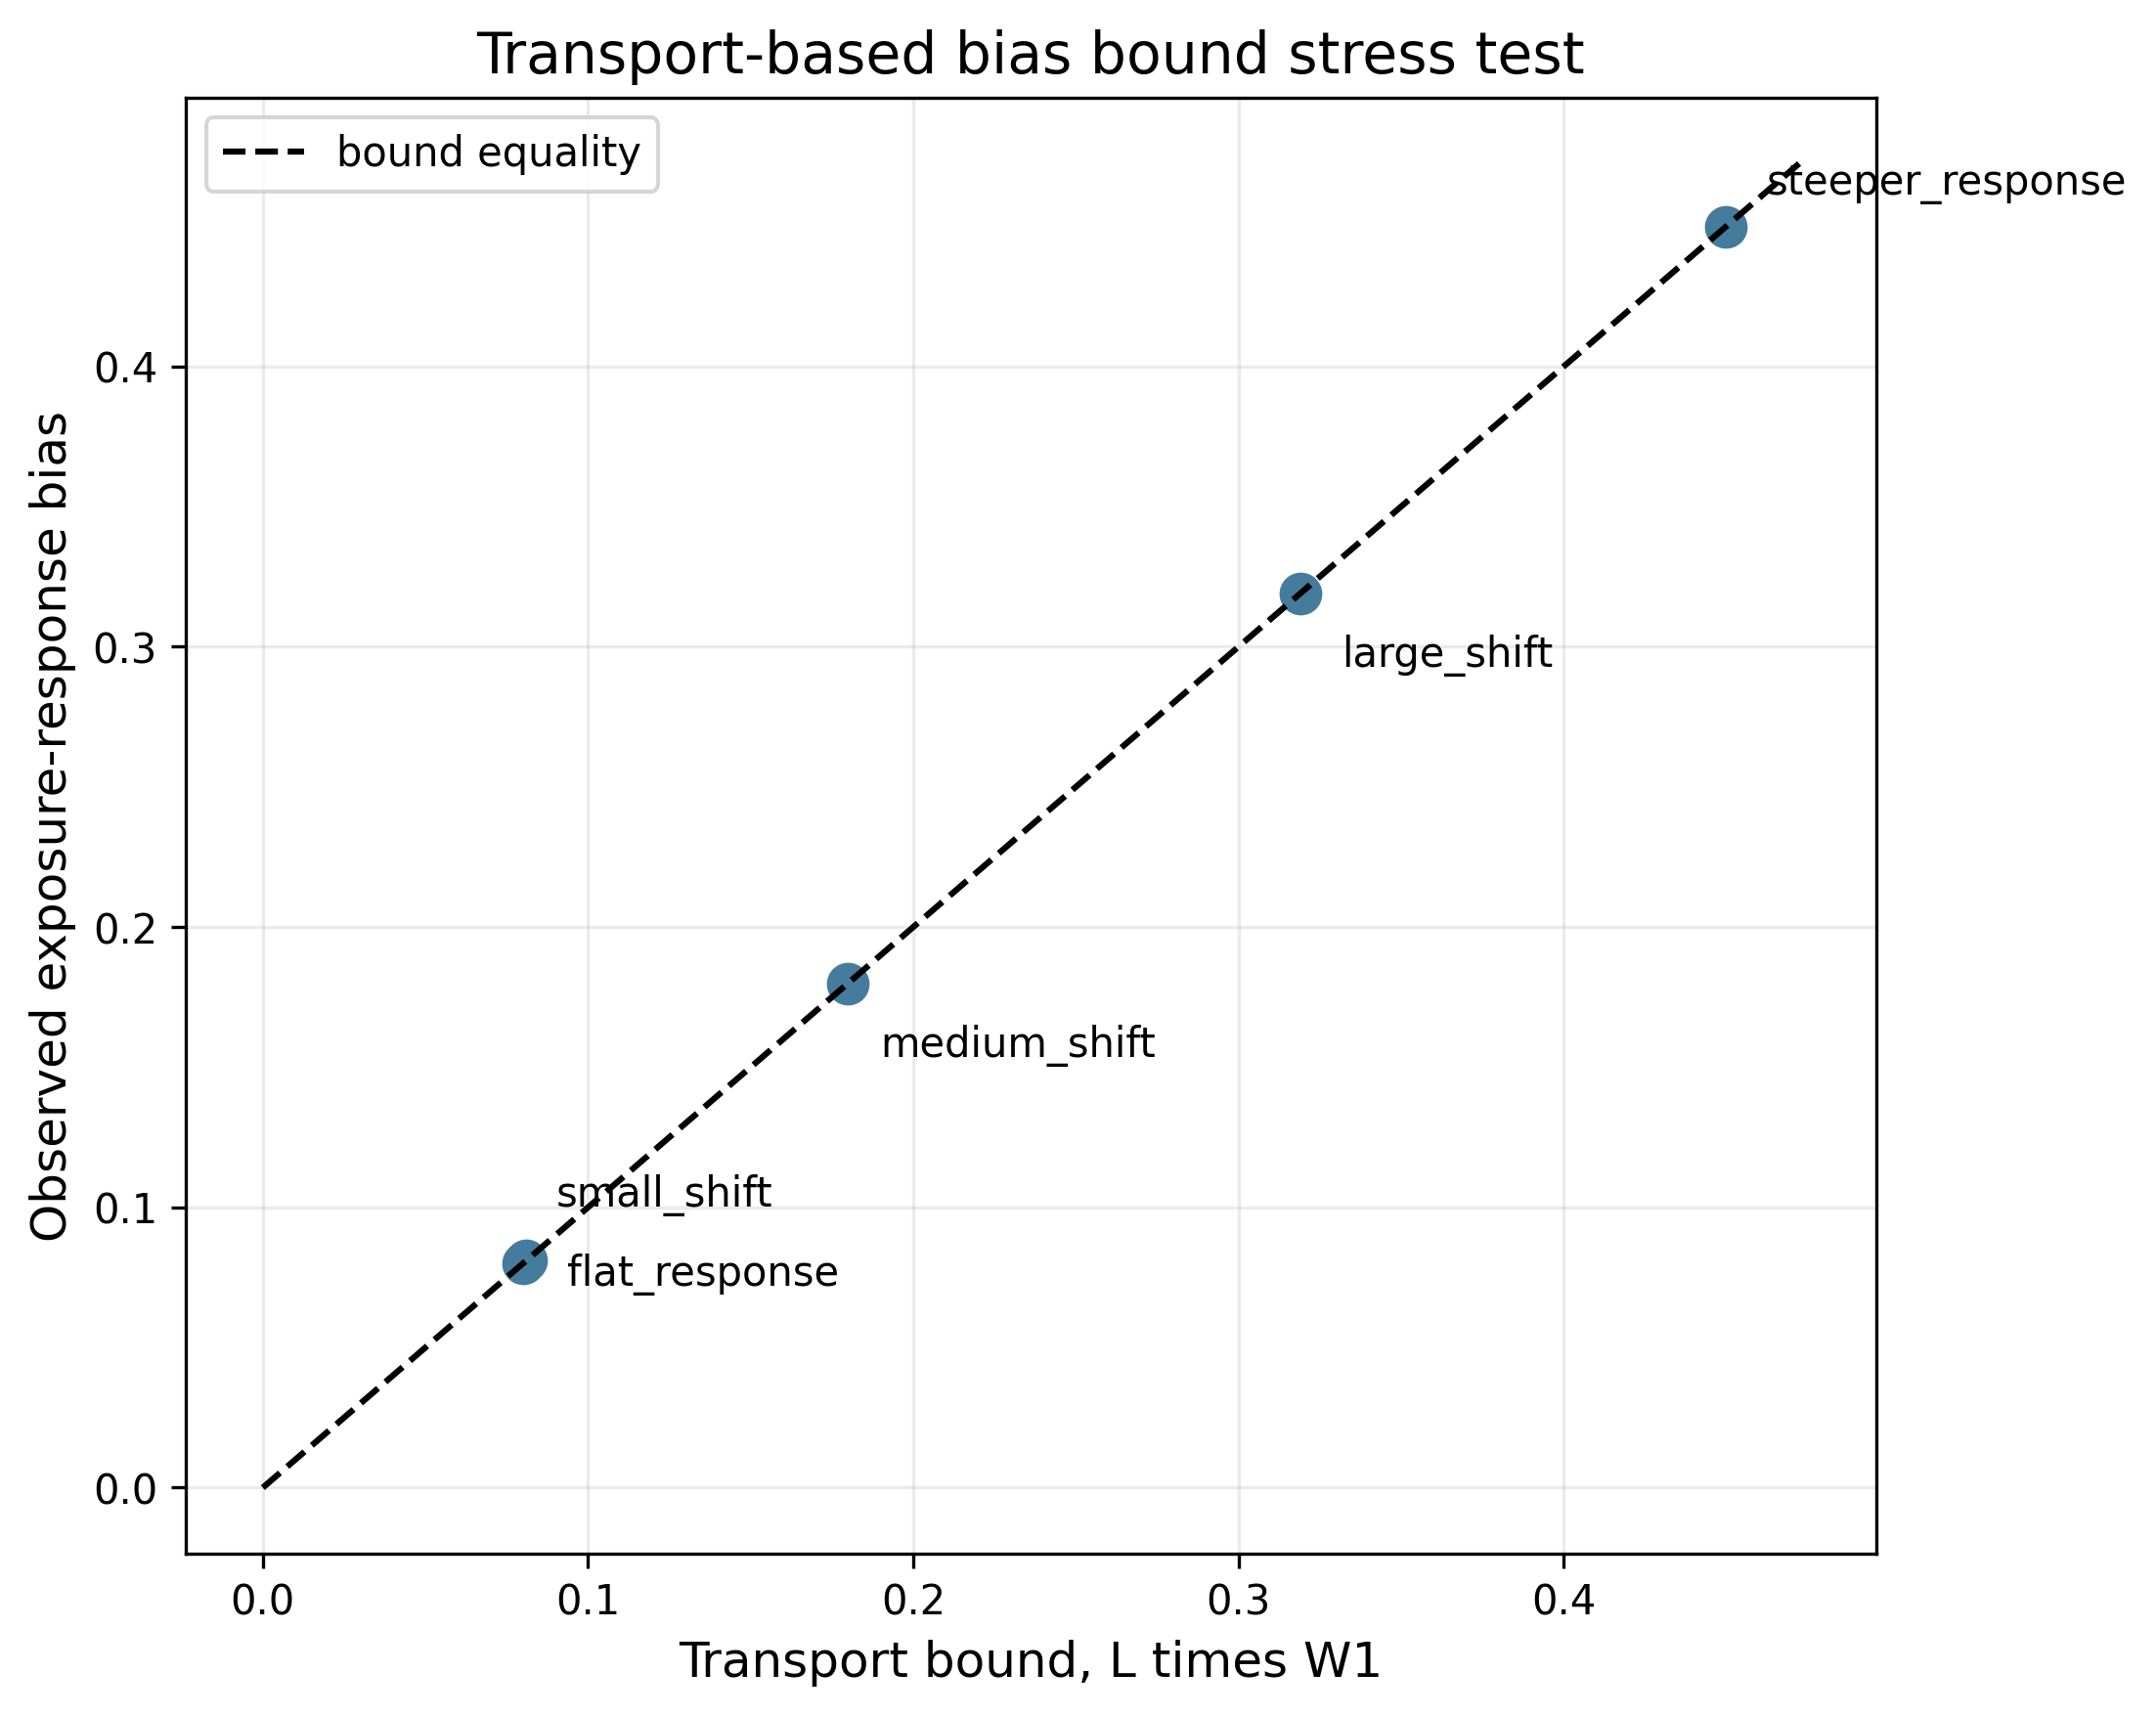

,scenario,lipschitz_constant,w1_exposure_distance,observed_bias,transport_bound,bias_to_bound_ratio,bound_holds
0,small_shift,1.00,0.080000,0.080000,0.080000,1.0,True
1,medium_shift,1.00,0.179942,0.179942,0.179942,1.0,True
2,large_shift,1.00,0.319065,0.319065,0.319065,1.0,True
3,steeper_response,2.50,0.179942,0.449855,0.449855,1.0,True
4,flat_response,0.45,0.179942,0.080974,0.080974,1.0,True


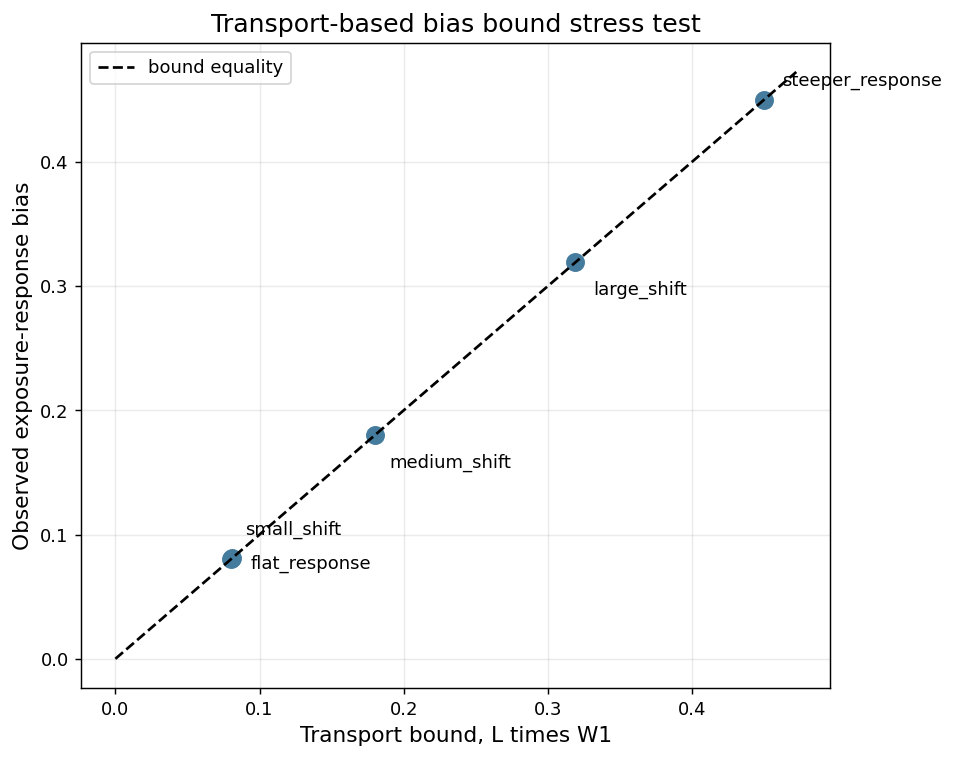

In [3]:
progress.log("running transport-bound stress test")
transport = run_transport_bias_bound_stress()
write_table(transport, paths.table_dir / "07_transport_bias_bound_stress.csv")
fig_path = paths.figure_dir / "07_transport_bias_bound_stress.png"
plot_transport_bound_checks(transport, fig_path)
display(Image(filename=str(fig_path)))
transport

## Theorem 4.2 stress test: minimax optimality of exposure geometry

Theorem 4.2 is the anchor result. It says that the Wasserstein exposure term is not only a convenient penalty. Within the class of Lipschitz exposure-response functions, it is the minimax-sharp penalty. The check below constructs response functions that attain the bound for simple shifted exposure distributions.

[04:29:27] 07-theory: running minimax transport optimality check
[saved] /home/apex/Documents/ranking_sys/notebooks/writing/online_experiment_designs_under_interference/code/artifacts/tables/07_minimax_transport_optimality.csv
[saved] /home/apex/Documents/ranking_sys/notebooks/writing/online_experiment_designs_under_interference/code/artifacts/figures/07_minimax_transport_optimality.png


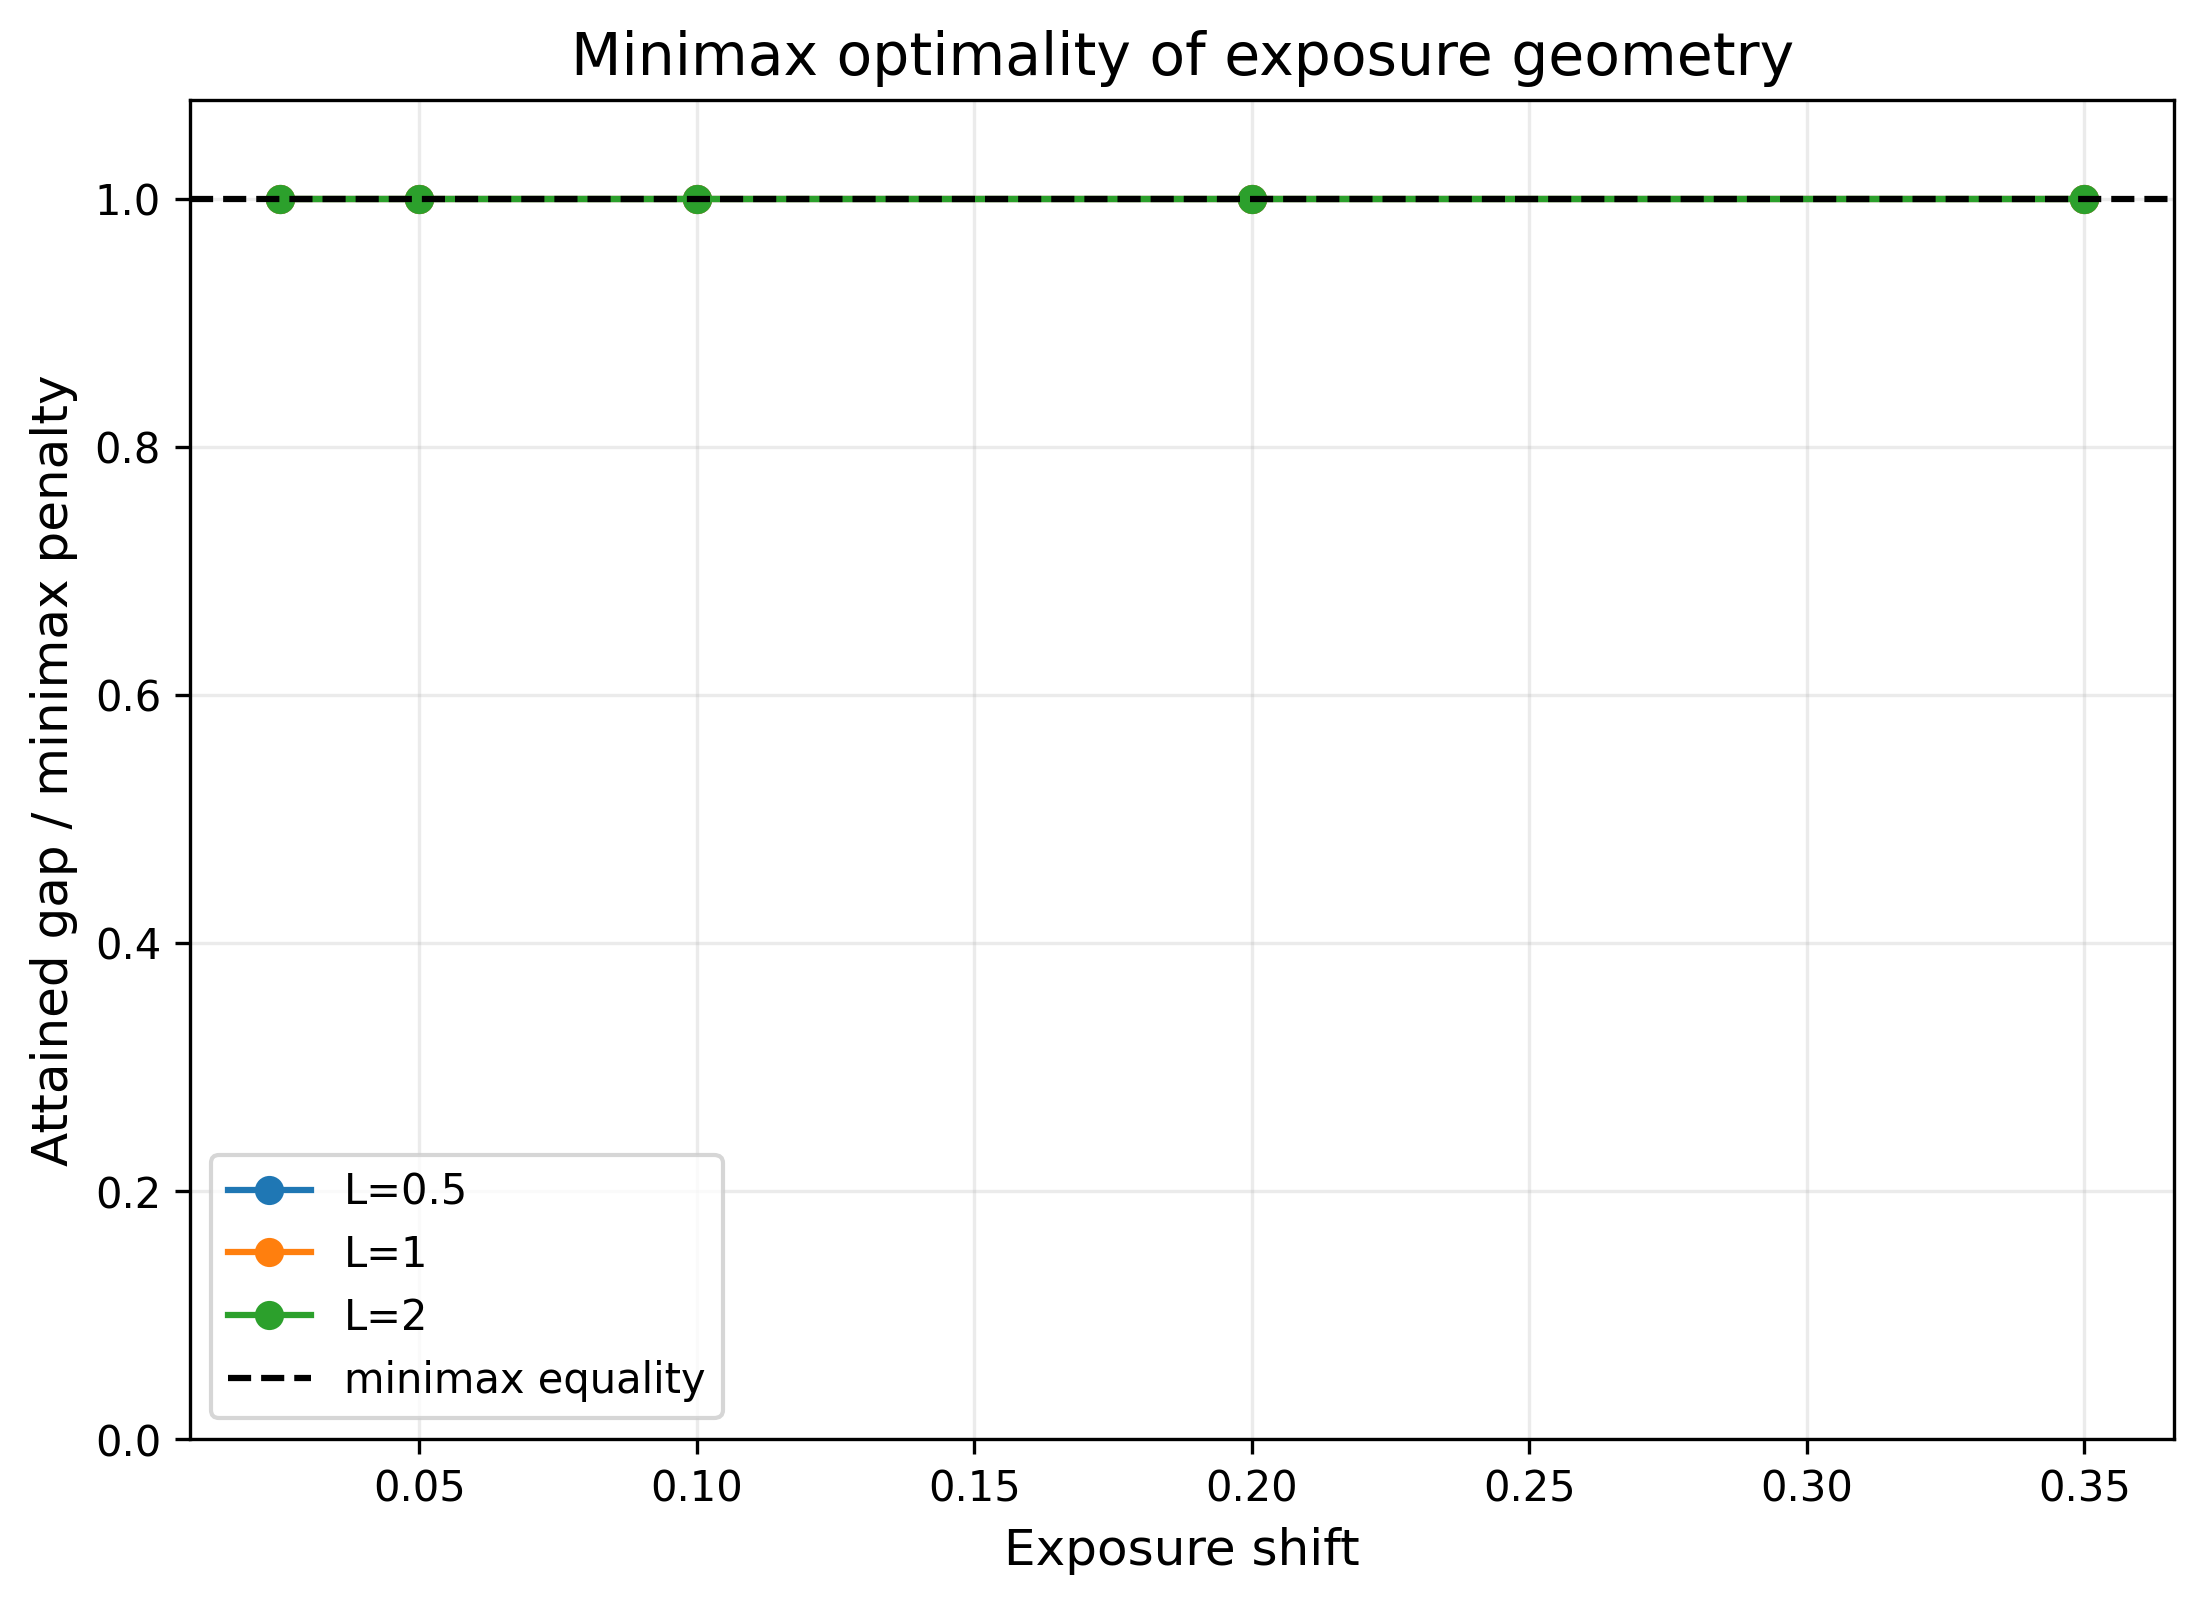

,delta,lipschitz_constant,w1_exposure_distance,attained_gap,minimax_penalty,attainment_ratio
0,0.025,0.5,0.025,0.0125,0.0125,1.0
1,0.025,1.0,0.025,0.0250,0.0250,1.0
2,0.025,2.0,0.025,0.0500,0.0500,1.0
3,0.050,0.5,0.050,0.0250,0.0250,1.0
4,0.050,1.0,0.050,0.0500,0.0500,1.0
5,0.050,2.0,0.050,0.1000,0.1000,1.0
6,0.100,0.5,0.100,0.0500,0.0500,1.0
7,0.100,1.0,0.100,0.1000,0.1000,1.0
8,0.100,2.0,0.100,0.2000,0.2000,1.0
9,0.200,0.5,0.200,0.1000,0.1000,1.0


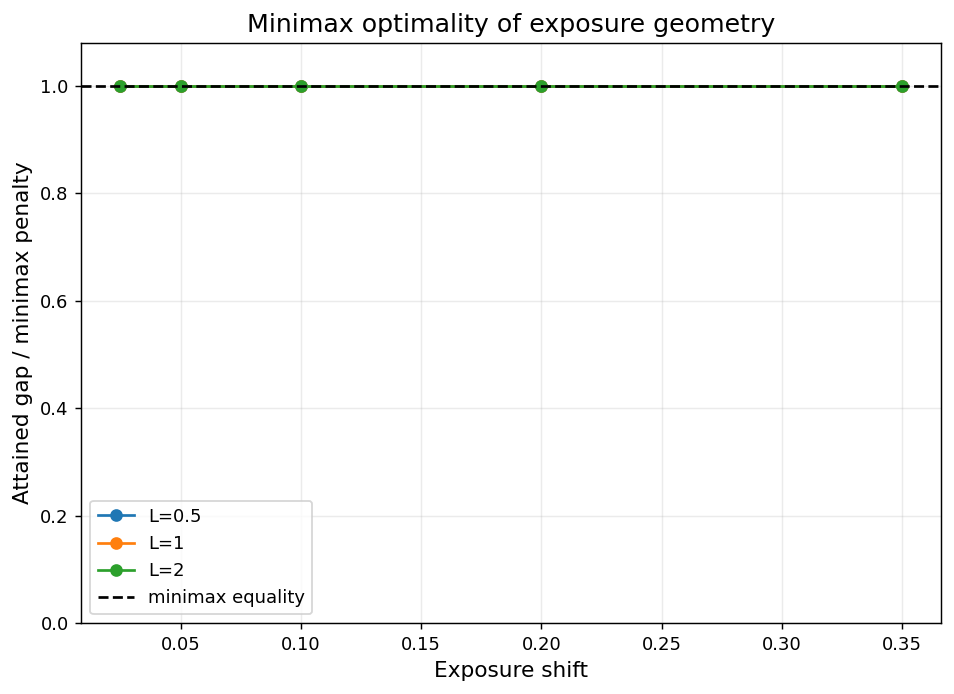

In [4]:
progress.log("running minimax transport optimality check")
minimax = run_minimax_transport_optimality_check()
write_table(minimax, paths.table_dir / "07_minimax_transport_optimality.csv")
fig_path = paths.figure_dir / "07_minimax_transport_optimality.png"
plot_minimax_transport_check(minimax, fig_path)
display(Image(filename=str(fig_path)))
minimax

## Proposition 4.3 stress test: finite catalog approximation

Proposition 4.3 justifies optimizing over an implementable finite design catalog when that catalog forms a sufficiently fine net over the underlying continuous design family. The stress test below uses a smooth one-dimensional risk surface with a known continuous optimum. As the catalog becomes denser, the empirical approximation gap should shrink and remain below the Lipschitz-net bound.

[04:29:27] 07-theory: running finite-catalog approximation check
[saved] /home/apex/Documents/ranking_sys/notebooks/writing/online_experiment_designs_under_interference/code/artifacts/tables/07_catalog_approximation_sensitivity.csv
[saved] /home/apex/Documents/ranking_sys/notebooks/writing/online_experiment_designs_under_interference/code/artifacts/figures/07_catalog_approximation_sensitivity.png


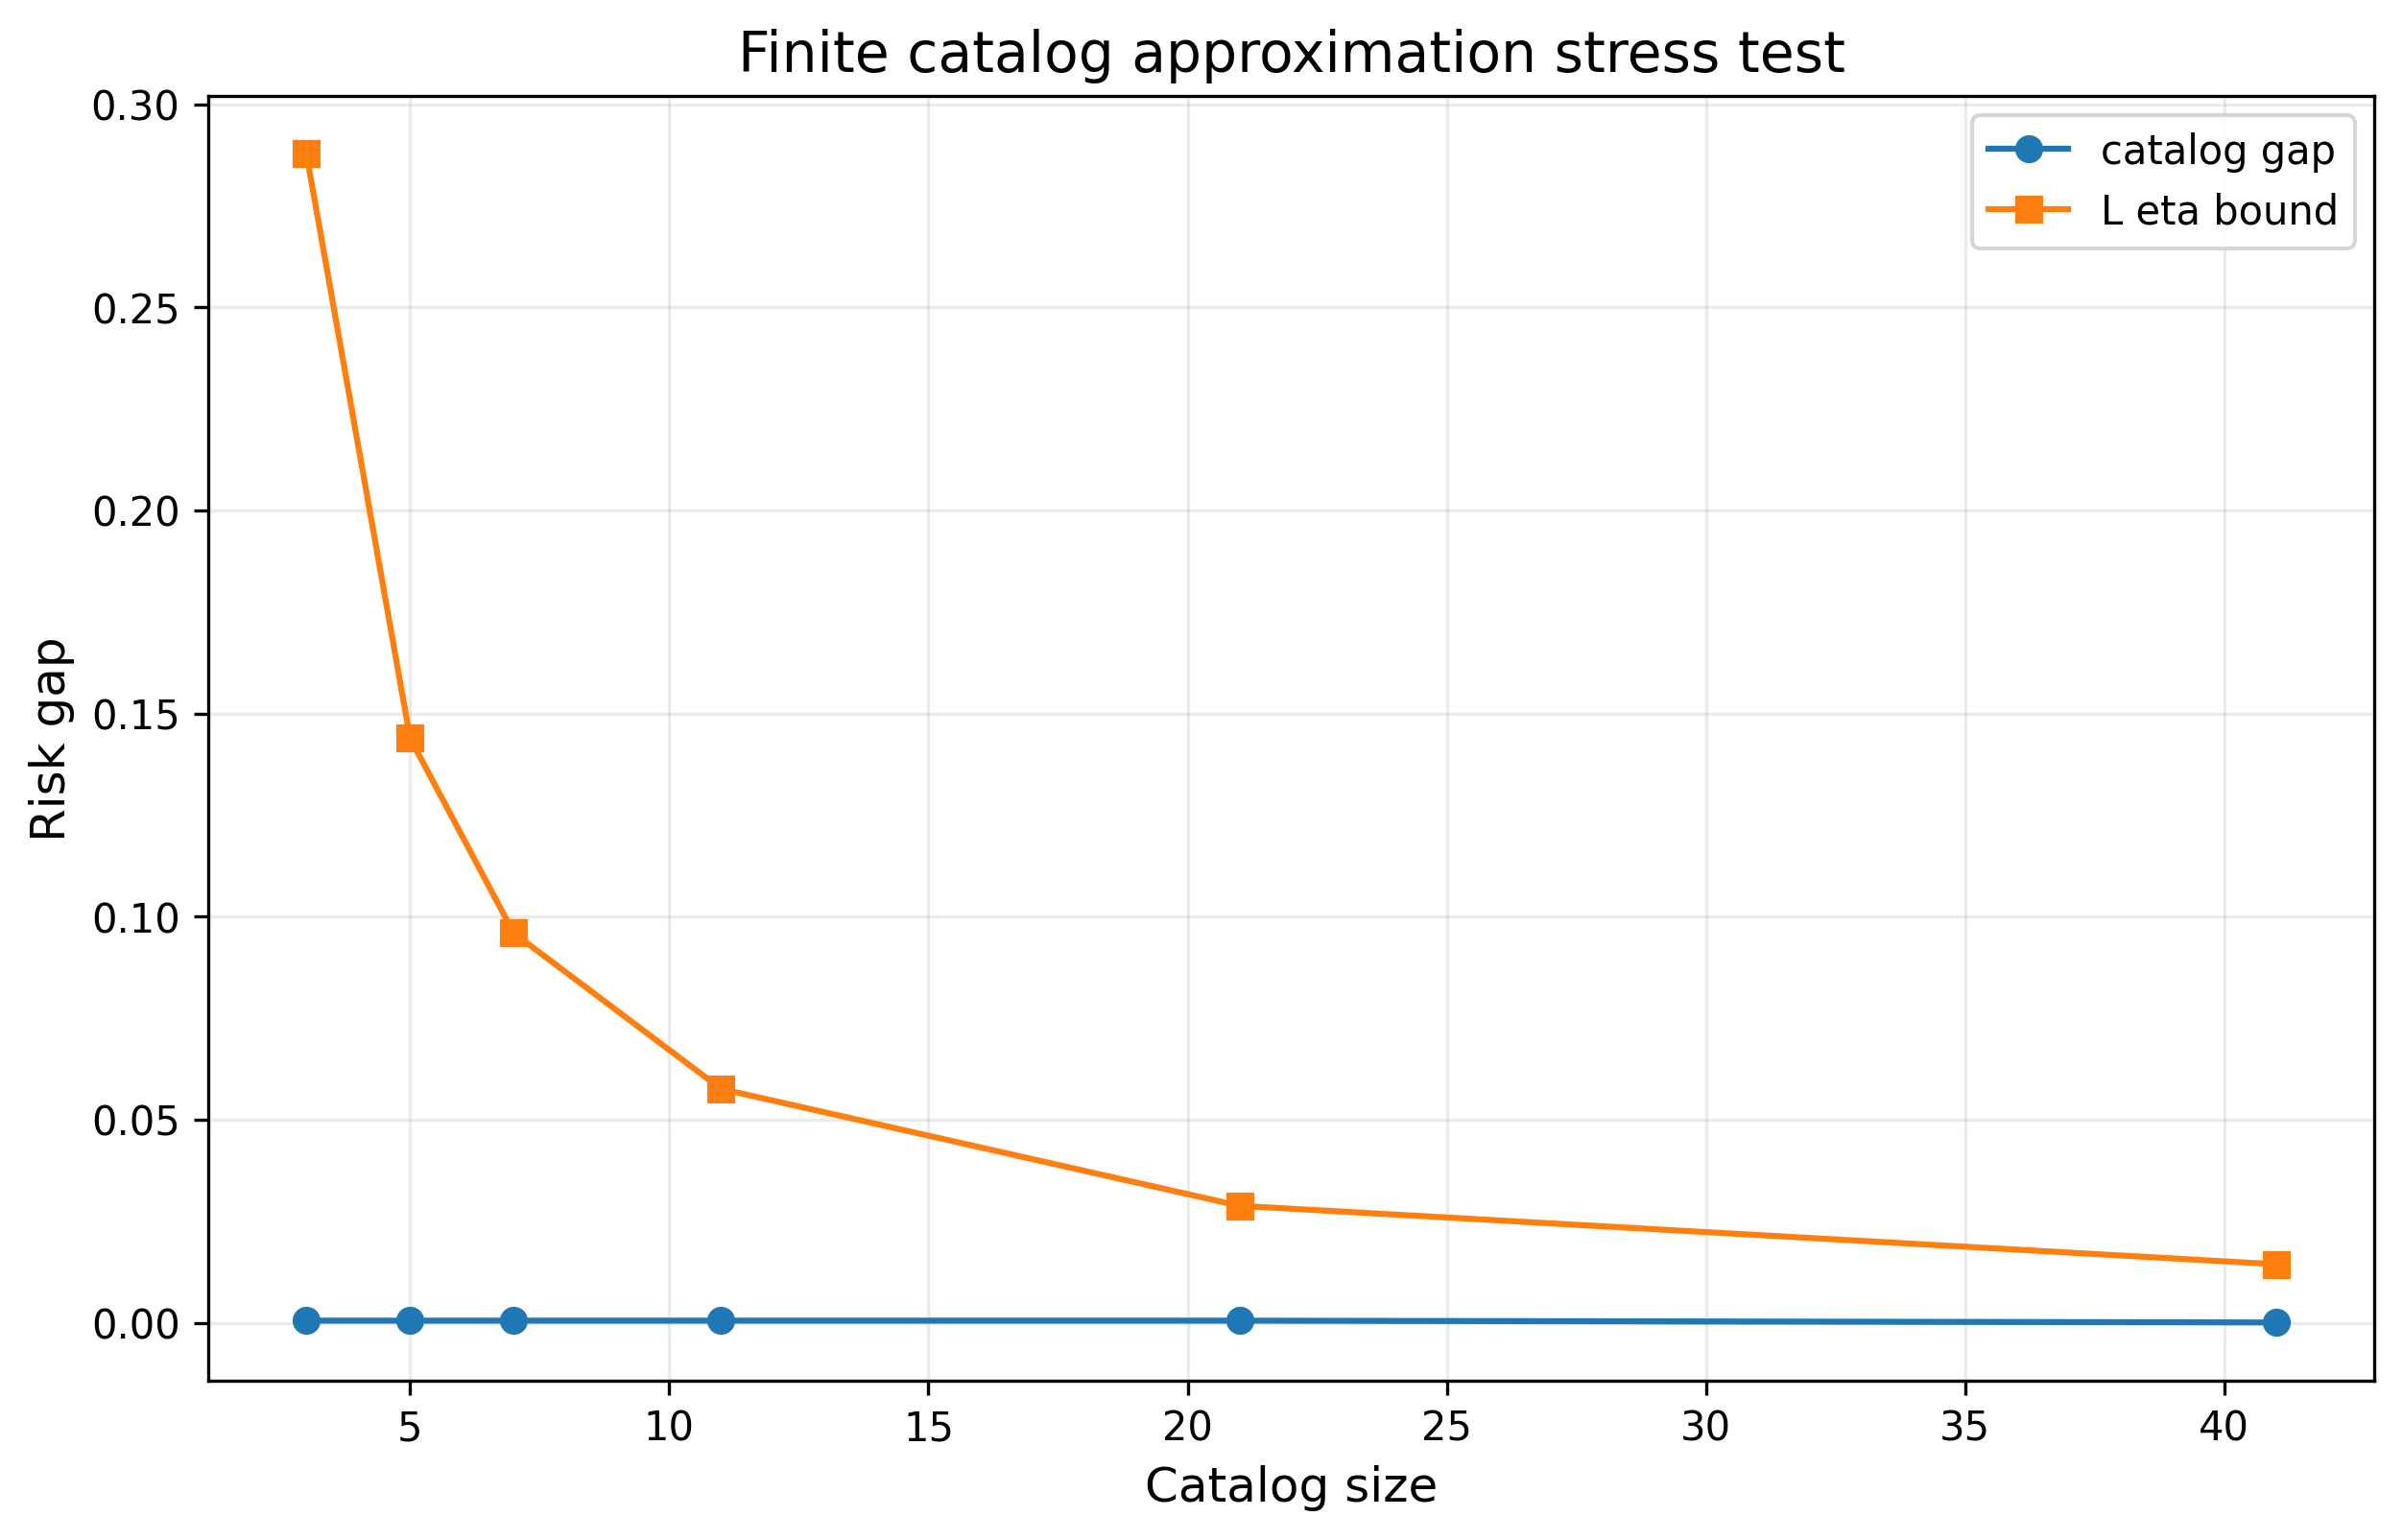

,catalog_size,eta_net_radius,continuous_best_risk,catalog_best_risk,approximation_gap,lipschitz_eta_bound,bound_holds
0,3,0.250000,0.040328,0.040827,0.000499,0.287797,True
1,5,0.125000,0.040328,0.040827,0.000499,0.143898,True
2,7,0.083333,0.040328,0.040827,0.000499,0.095932,True
3,11,0.050000,0.040328,0.040827,0.000499,0.057559,True
4,21,0.025000,0.040328,0.040827,0.000499,0.028780,True
5,41,0.012500,0.040328,0.040383,0.000055,0.014390,True


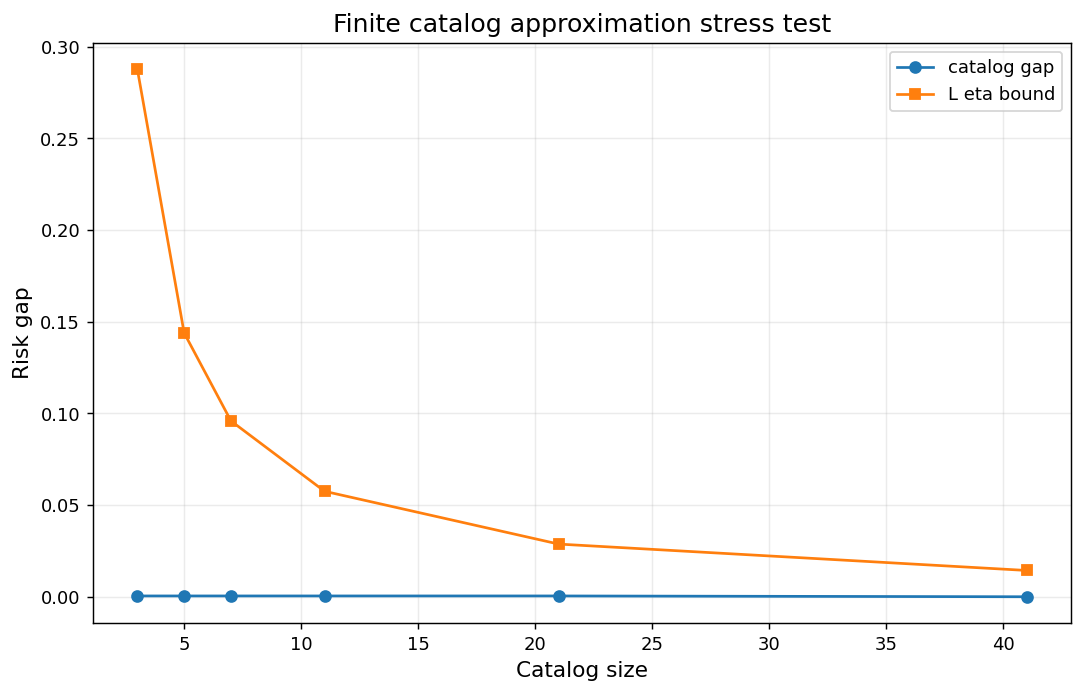

In [5]:
progress.log("running finite-catalog approximation check")
catalog = run_catalog_approximation_sensitivity()
write_table(catalog, paths.table_dir / "07_catalog_approximation_sensitivity.csv")
fig_path = paths.figure_dir / "07_catalog_approximation_sensitivity.png"
plot_catalog_approximation(catalog, fig_path)
display(Image(filename=str(fig_path)))
catalog

## Assignment-unit MDE planning check

The planning MDE calculation is not a separate novelty theorem, but it is a key operational ingredient in the risk score. This grid verifies that the detectable-effect proxy behaves as expected. Designs with fewer effective assignment units or larger assignment-unit variance need longer validation windows to detect the same effect size.

[04:29:28] 07-theory: running assignment-unit MDE grid
[saved] /home/apex/Documents/ranking_sys/notebooks/writing/online_experiment_designs_under_interference/code/artifacts/tables/07_assignment_unit_mde_grid.csv
[saved] /home/apex/Documents/ranking_sys/notebooks/writing/online_experiment_designs_under_interference/code/artifacts/figures/07_assignment_unit_mde_grid.png


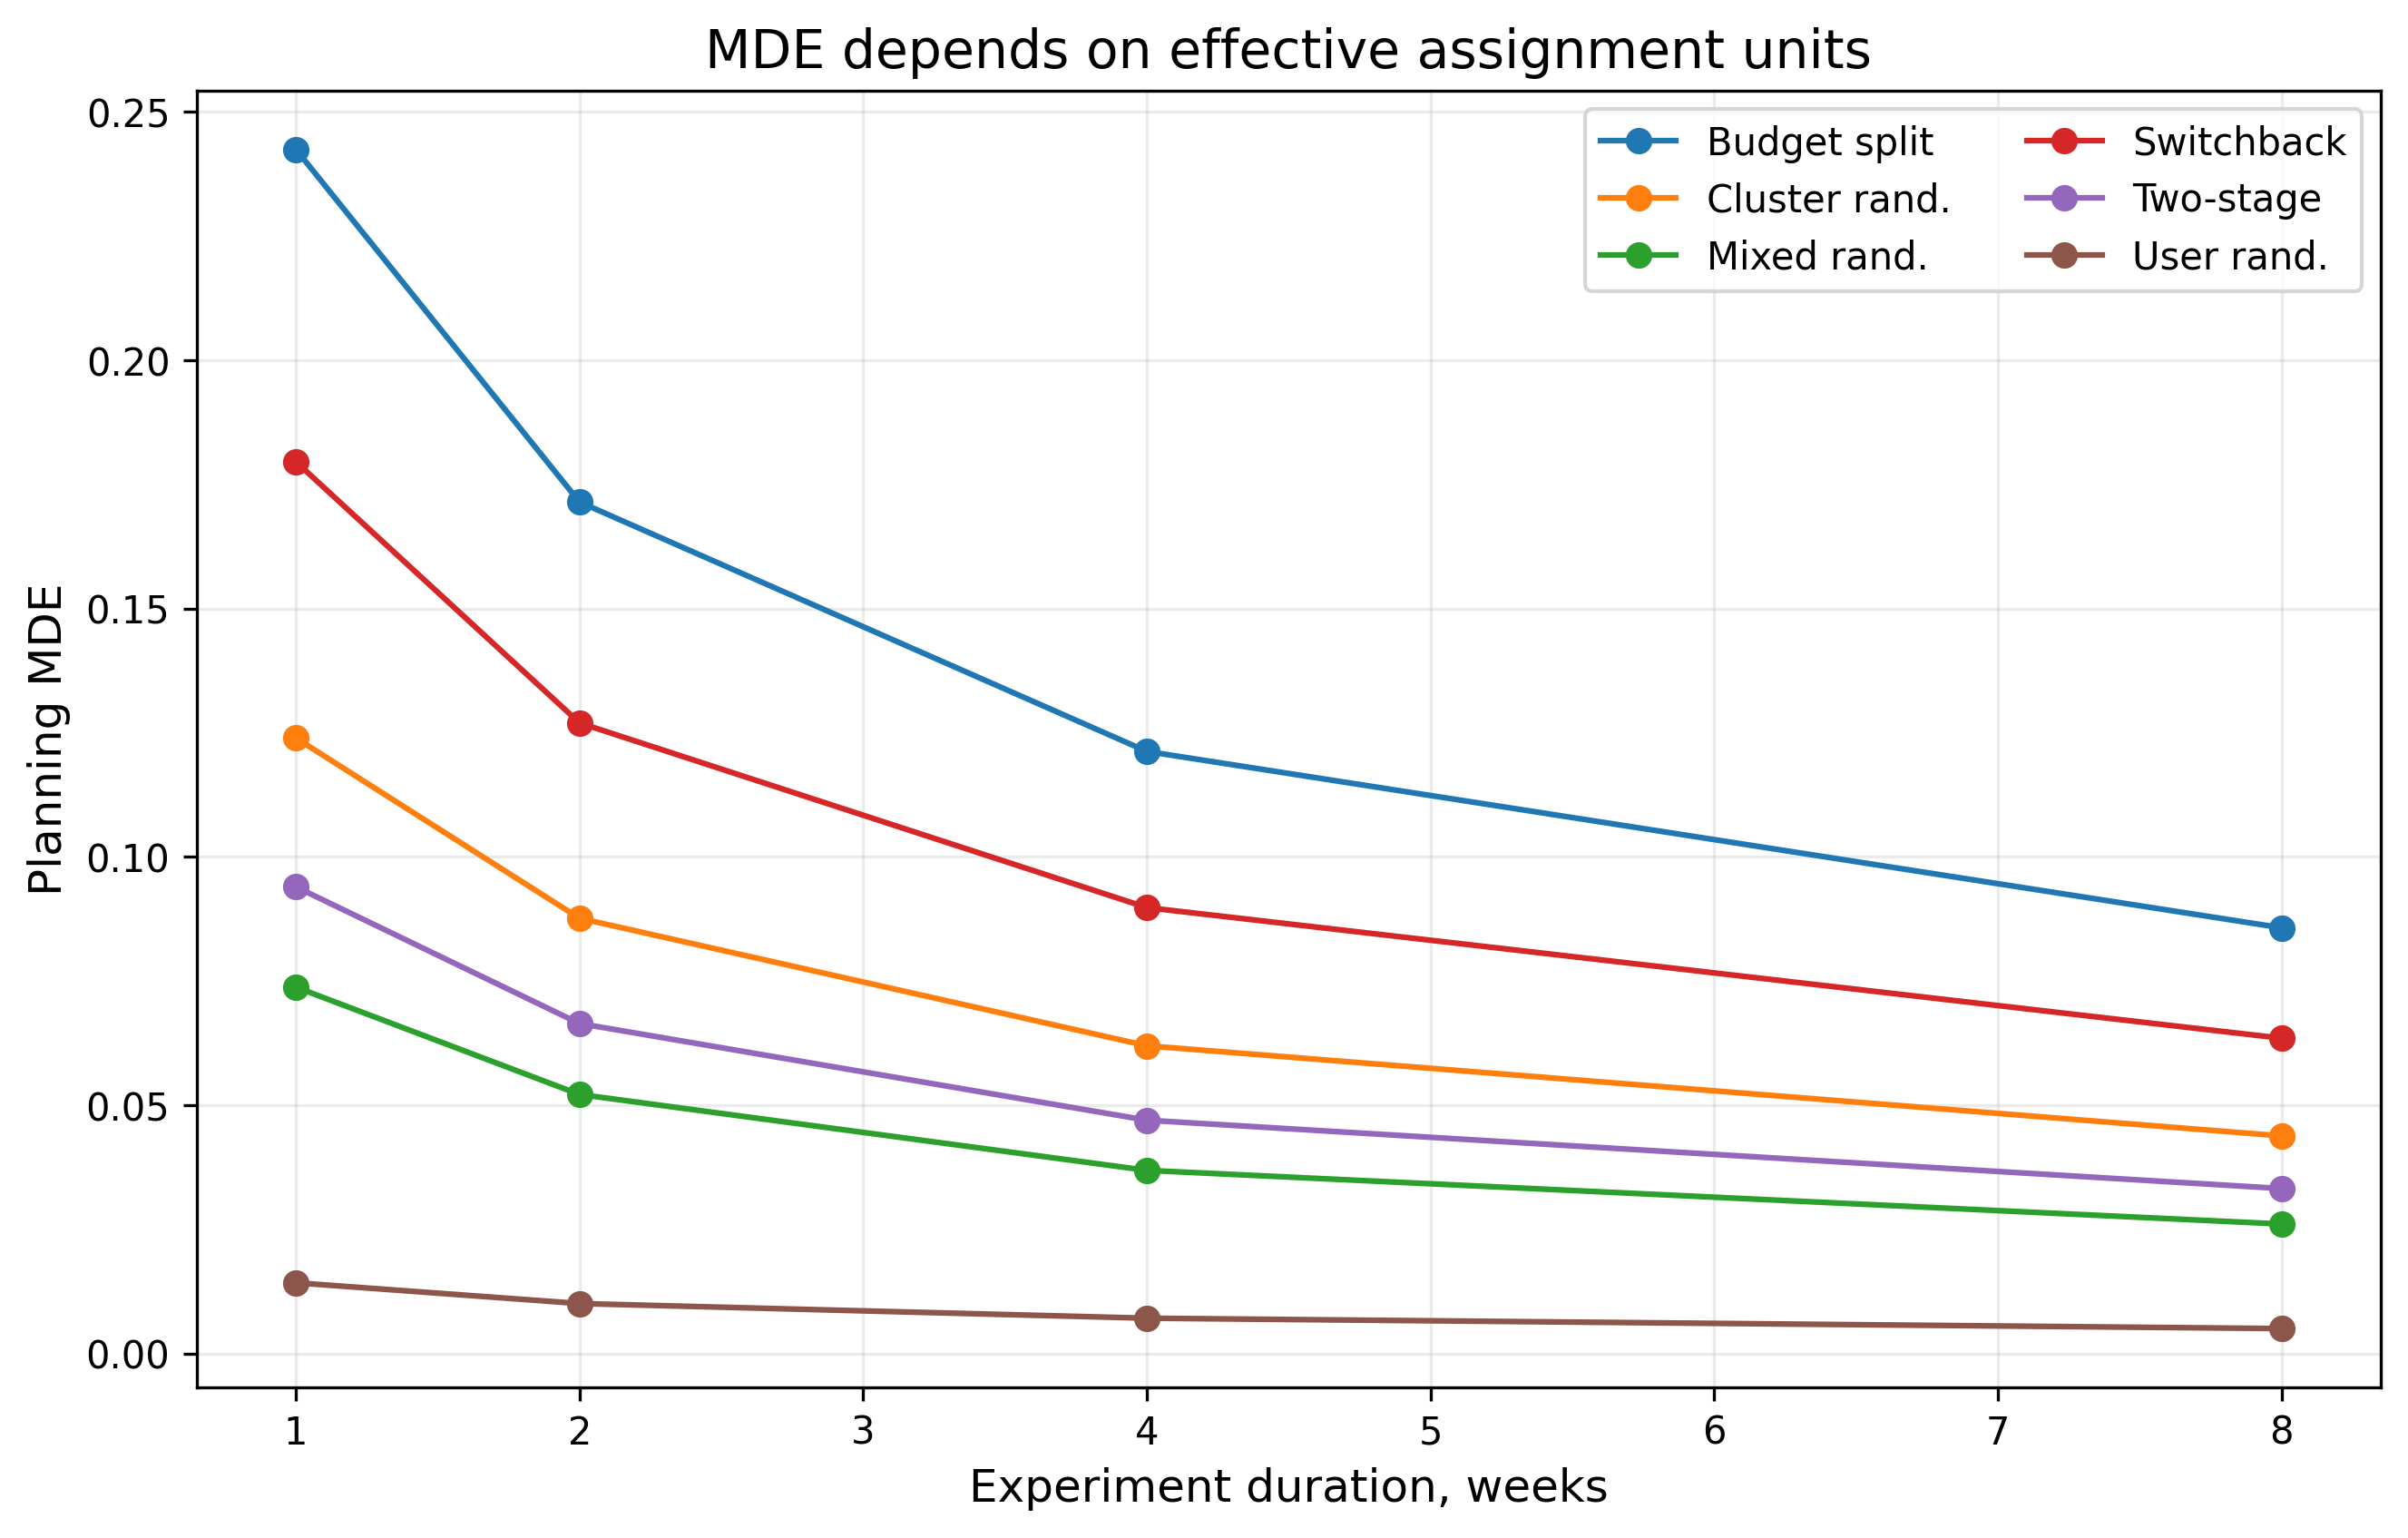

,design,weeks,effective_assignment_units,assignment_unit_sd,assignment_unit_variance,planning_mde
0,user_randomization,1,2500,0.18,0.0324,0.014255
1,user_randomization,2,5000,0.18,0.0324,0.010080
2,user_randomization,4,10000,0.18,0.0324,0.007128
3,user_randomization,8,20000,0.18,0.0324,0.005040
4,cluster_randomization,1,80,0.28,0.0784,0.123961
5,cluster_randomization,2,160,0.28,0.0784,0.087654
6,cluster_randomization,4,320,0.28,0.0784,0.061981
7,cluster_randomization,8,640,0.28,0.0784,0.043827
8,switchback,1,28,0.24,0.0576,0.179600
9,switchback,2,56,0.24,0.0576,0.126996


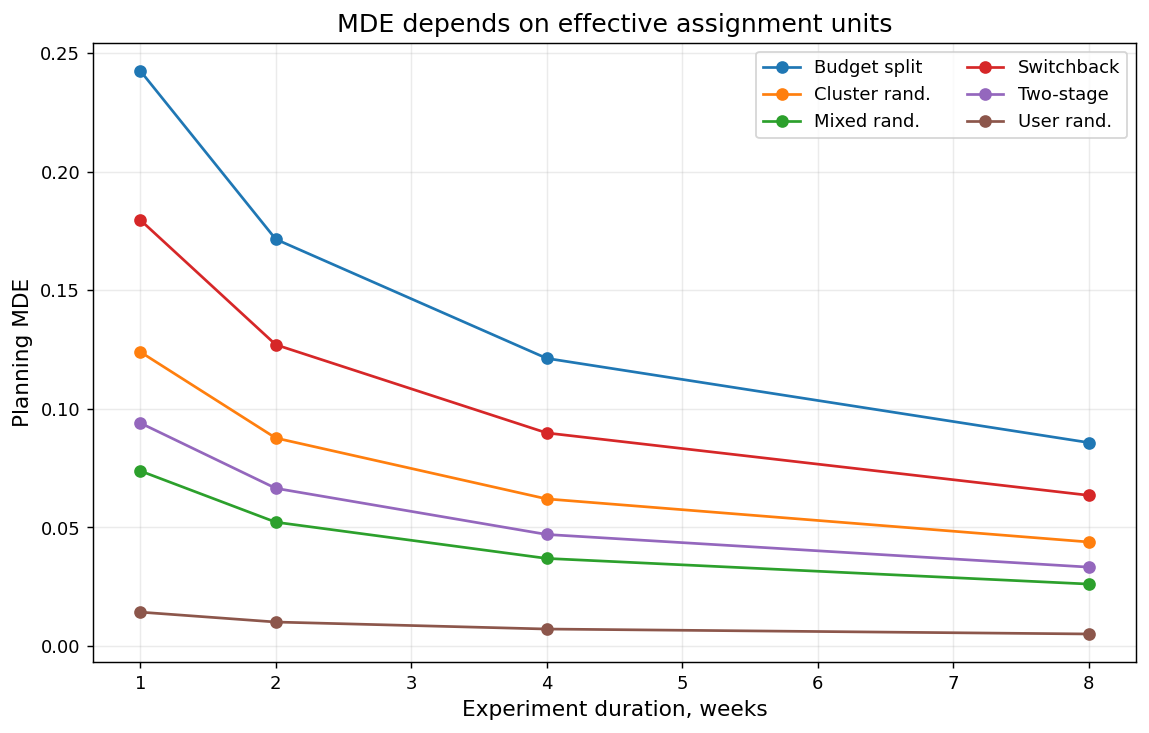

In [6]:
progress.log("running assignment-unit MDE grid")
mde_grid = run_assignment_unit_mde_grid()
write_table(mde_grid, paths.table_dir / "07_assignment_unit_mde_grid.csv")
fig_path = paths.figure_dir / "07_assignment_unit_mde_grid.png"
plot_assignment_unit_mde(mde_grid, fig_path)
display(Image(filename=str(fig_path)))
mde_grid

## Placement note

The main body should use the synthetic selector, Criteo, Open Bandit, KuaiRand, graph, and cross-domain notebooks to tell the design-selection story. The tables and figures from this notebook are better suited for Appendix B because they validate the mathematical claims in isolation and keep the main empirical narrative focused on domain behavior.